# Grid Rainout Convergence Check

Inspects `monitor.dat` files from the HELIOS + FastChem rainout runs on the cluster.

**Grid:** 200–1600 K (×200 K steps) × the full pressure range in each file  
**Compositions:** EH3, EL3, R3, Krymka(LL3), Bath(H4)  
**Cluster path:** `output/grid_day/{T}K_{type}_day/chemistry/monitor.dat`

Checks:
1. Overall convergence (`converged` flag)
2. Element conservation (`elem_conserved` flag + per-element)
3. Iteration counts (very high counts indicate a struggling solver)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path

# ── Configuration ────────────────────────────────────────────────────────────
OUTPUT_ROOT = Path("output/grid_day")

TEMPERATURES = [200, 400, 600, 800, 1000, 1200, 1400, 1600]  # K

# Map display name → folder slug used in the cluster path
COMPOSITIONS = {
    "EH3":         "EH3",
    "EL3":         "EL3",
    "R3":          "R3",
    "Krymka(LL3)": "Krymka(LL3)",
    "Bath(H4)":    "Bath(H4)",
    "asplund_m3" : "asplund_m3",
}

FIXED_COLS = {
    "grid_point", "iterations", "chem_iter", "cond_iter",
    "converged", "elem_conserved", "p_bar", "T_K",
    "ntot_cmneg3", "n_g_cmneg3", "m_u",
}

# Scatter plot marker size
MS = 12

In [11]:
def parse_monitor(path):
    """Parse one monitor.dat into a DataFrame.
    ok/fail string columns → bool (True = ok).
    """
    with open(path) as f:
        header_line = f.readline().lstrip("#").strip()

    raw_cols = [c.strip() for c in header_line.split("\t") if c.strip()]
    cols = [
        c.replace("(", "_").replace(")", "")
         .replace("-", "neg").replace("<", "").replace(">", "")
        for c in raw_cols
    ]

    df = pd.read_csv(path, sep=r"\s+", comment="#", header=None, names=cols)

    bool_cols = [c for c in ["converged", "elem_conserved"] if c in df.columns]
    bool_cols += [c for c in cols[11:] if c in df.columns]
    for col in bool_cols:
        if df[col].dtype == object:
            df[col] = df[col].str.strip() == "ok"
        else:
            # Coerce int/float (e.g. all-same column pandas may infer as int)
            df[col] = df[col].astype(bool)

    return df


def load_composition(slug):
    """Load and concatenate monitor.dat for all temperatures for one composition."""
    frames = []
    missing = []
    for T in TEMPERATURES:
        path = OUTPUT_ROOT / f"{T}K_{slug}_day" / "chemistry" / "monitor.dat"
        if path.exists():
            frames.append(parse_monitor(path))
        else:
            missing.append(T)

    if missing:
        print(f"  [{slug}] missing T = {missing} K")
    if not frames:
        return None
    return pd.concat(frames, ignore_index=True)


# Load all compositions
all_data = {}
for label, slug in COMPOSITIONS.items():
    df = load_composition(slug)
    if df is not None:
        all_data[label] = df
        print(f"{label}: {len(df)} grid points")
    else:
        print(f"{label}: NO DATA FOUND")

EH3: 600 grid points
EL3: 600 grid points
R3: 600 grid points
Krymka(LL3): 600 grid points
Bath(H4): 600 grid points
asplund_m3: 600 grid points


In [12]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for label, df in all_data.items():
    n_total     = len(df)
    n_conv_fail = (~df["converged"]).sum()      if "converged"      in df.columns else np.nan
    n_elem_fail = (~df["elem_conserved"]).sum() if "elem_conserved" in df.columns else np.nan
    rows.append({
        "Composition":         label,
        "Total points":        n_total,
        "converged=FAIL":      int(n_conv_fail),
        "elem_conserved=FAIL": int(n_elem_fail),
        "Fully OK":            int(n_total - max(n_conv_fail, n_elem_fail)),
    })

summary = pd.DataFrame(rows).set_index("Composition")
display(summary)

,Total points,converged=FAIL,elem_conserved=FAIL,Fully OK
Composition,,,,
EH3,600,0,7,593
EL3,600,54,61,539
R3,600,16,18,582
Krymka(LL3),600,30,32,568
Bath(H4),600,0,8,592
asplund_m3,600,0,0,600


## 1. Convergence Map

Each point is one (T, P) cell. Color: green = OK, orange = element conservation failed, red = did not converge.

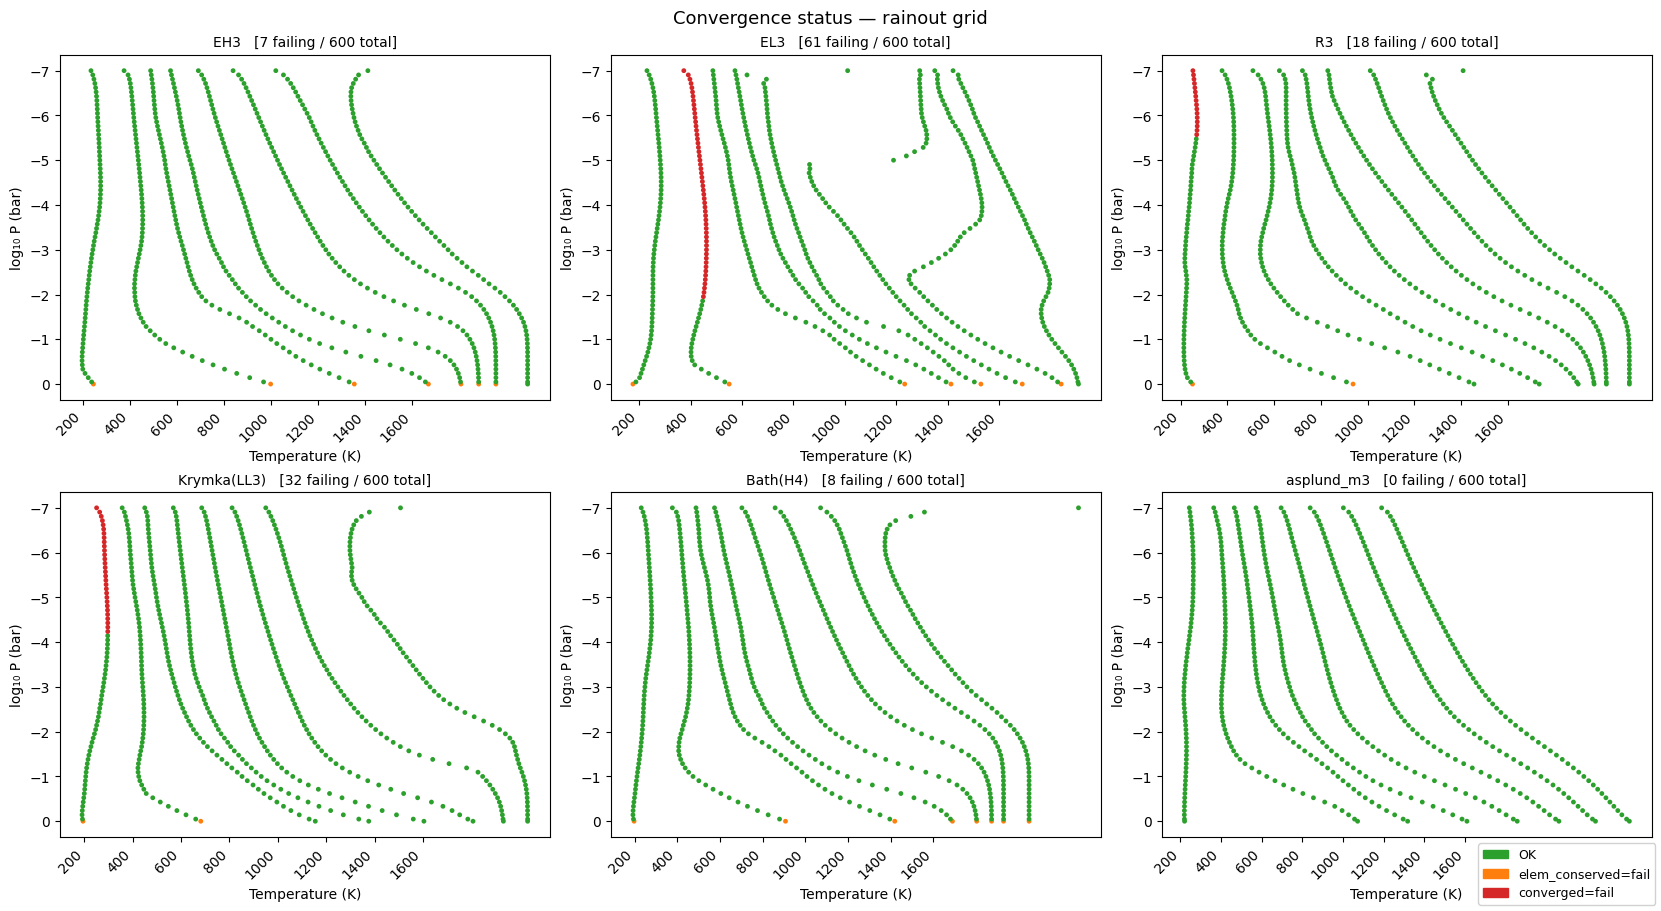

In [13]:
STATUS_COLORS = ["#2ca02c", "#ff7f0e", "#d62728"]   # ok / elem fail / not converged
STATUS_LABELS = ["OK", "elem_conserved=fail", "converged=fail"]

def convergence_status(df):
    """0=ok, 1=elem_fail, 2=not_converged (worst wins)."""
    status = np.zeros(len(df), dtype=int)
    if "elem_conserved" in df.columns:
        status[~df["elem_conserved"].values] = 1
    if "converged" in df.columns:
        status[~df["converged"].values] = 2
    return status


n = len(all_data)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows),
                          constrained_layout=True)
axes = np.array(axes).flatten()

for ax, (label, df) in zip(axes, all_data.items()):
    status = convergence_status(df)
    colors = [STATUS_COLORS[s] for s in status]

    ax.scatter(df["T_K"], np.log10(df["p_bar"]), c=colors, s=MS, linewidths=0)
    ax.set_xticks(TEMPERATURES)
    ax.set_xticklabels([str(t) for t in TEMPERATURES], rotation=45, ha="right")
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("log₁₀ P (bar)")
    ax.invert_yaxis()

    n_bad = (status > 0).sum()
    ax.set_title(f"{label}   [{n_bad} failing / {len(df)} total]", fontsize=10)

for ax in axes[n:]:
    ax.set_visible(False)

patches = [Patch(color=STATUS_COLORS[i], label=STATUS_LABELS[i]) for i in range(3)]
fig.legend(handles=patches, loc="lower right", fontsize=9, framealpha=0.9)
fig.suptitle("Convergence status — rainout grid", fontsize=13)
plt.show()

## 2. Iteration Count

High iteration counts can indicate the solver struggled even if it ultimately converged.  
Color scale is shared across compositions; clipped at the 99th percentile.

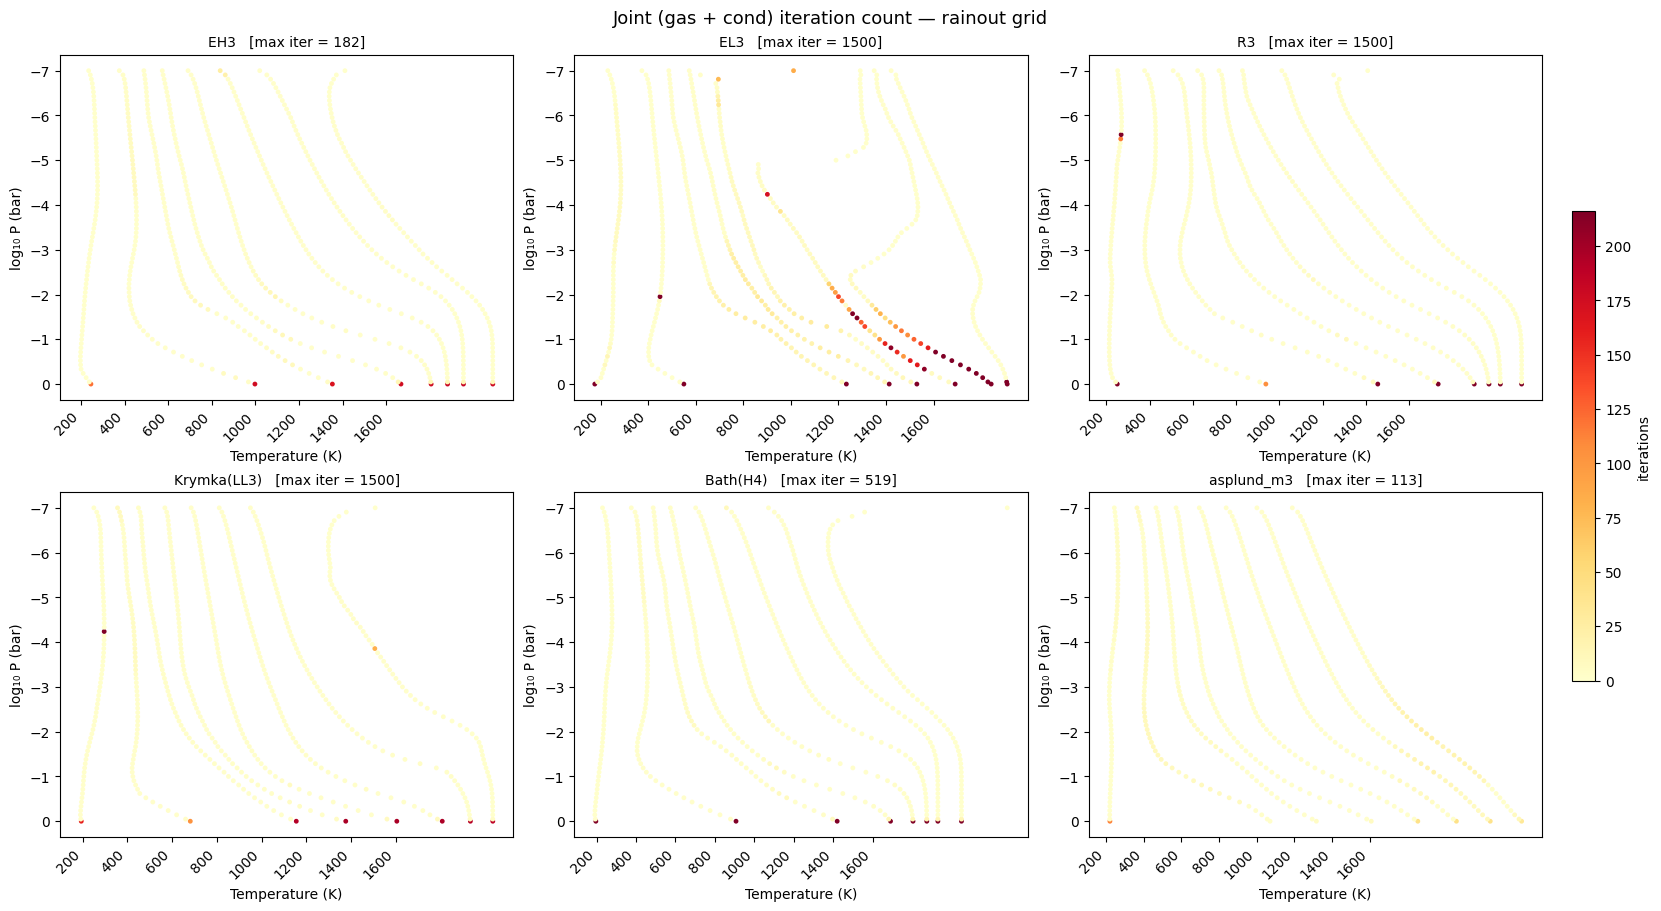

In [14]:
all_iters = pd.concat(
    df["iterations"] for df in all_data.values() if "iterations" in df.columns
)
iter_vmax = np.percentile(all_iters, 99)

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows),
                          constrained_layout=True)
axes = np.array(axes).flatten()

for ax, (label, df) in zip(axes, all_data.items()):
    sc = ax.scatter(
        df["T_K"], np.log10(df["p_bar"]),
        c=df["iterations"], cmap="YlOrRd",
        vmin=0, vmax=iter_vmax,
        s=MS, linewidths=0,
    )
    ax.set_xticks(TEMPERATURES)
    ax.set_xticklabels([str(t) for t in TEMPERATURES], rotation=45, ha="right")
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("log₁₀ P (bar)")
    ax.invert_yaxis()

    max_iter = df["iterations"].max()
    ax.set_title(f"{label}   [max iter = {max_iter}]", fontsize=10)

for ax in axes[n:]:
    ax.set_visible(False)

fig.colorbar(sc, ax=axes[:n], label="iterations", shrink=0.6, pad=0.02)
fig.suptitle("Joint (gas + cond) iteration count — rainout grid", fontsize=13)
plt.show()

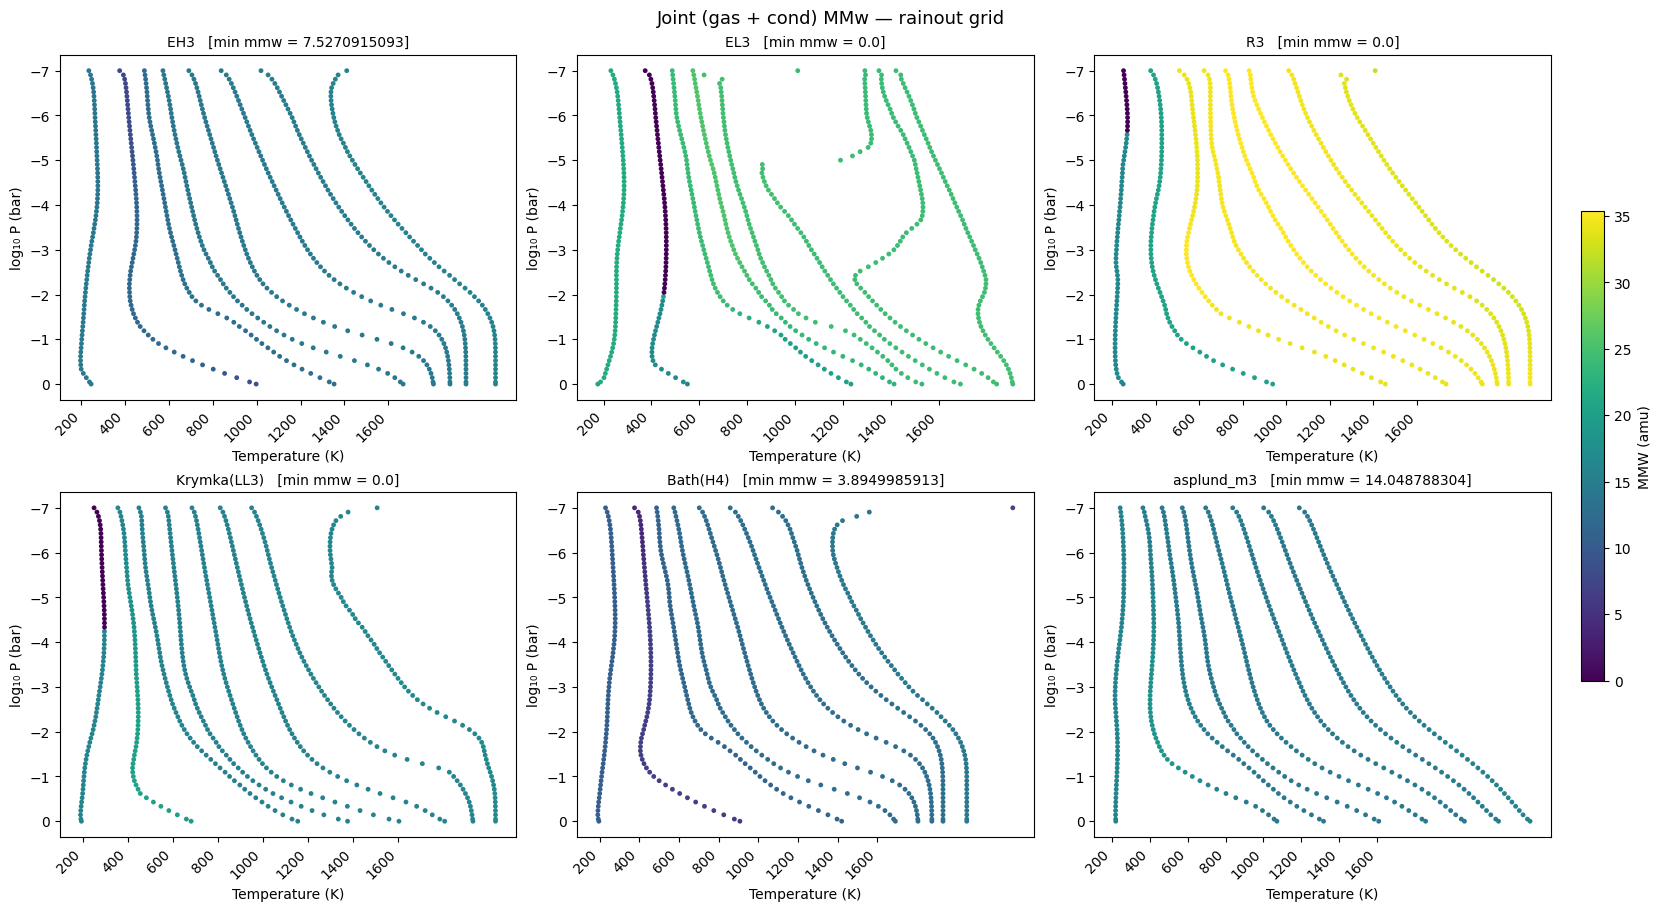

In [15]:
all_mmw = pd.concat(
    df["m_u"] for df in all_data.values() if "m_u" in df.columns
)
mmw_vmax = np.percentile(all_mmw, 99)

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows),
                          constrained_layout=True)
axes = np.array(axes).flatten()

for ax, (label, df) in zip(axes, all_data.items()):
    sc = ax.scatter(
        df["T_K"], np.log10(df["p_bar"]),
        c=df["m_u"], cmap="viridis",
        vmin=0, vmax=mmw_vmax,
        s=MS, linewidths=0,
    )
    ax.set_xticks(TEMPERATURES)
    ax.set_xticklabels([str(t) for t in TEMPERATURES], rotation=45, ha="right")
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("log₁₀ P (bar)")
    ax.invert_yaxis()

    min_mmw = df["m_u"].min()
    ax.set_title(f"{label}   [min mmw = {min_mmw}]", fontsize=10)

for ax in axes[n:]:
    ax.set_visible(False)

fig.colorbar(sc, ax=axes[:n], label="MMW (amu)", shrink=0.6, pad=0.02)
fig.suptitle("Joint (gas + cond) MMw — rainout grid", fontsize=13)
plt.show()

## 3. Per-Element Conservation Failures

For each composition with failures, one subplot per failed element.  
Green = conserved, red = failed.


────────────────────────────────────────────────────────────
EH3 — elements with conservation failures:
       H: 7 points
       N: 7 points
       C: 6 points
      Cl: 6 points
       F: 5 points
      Zn: 5 points
       P: 1 points


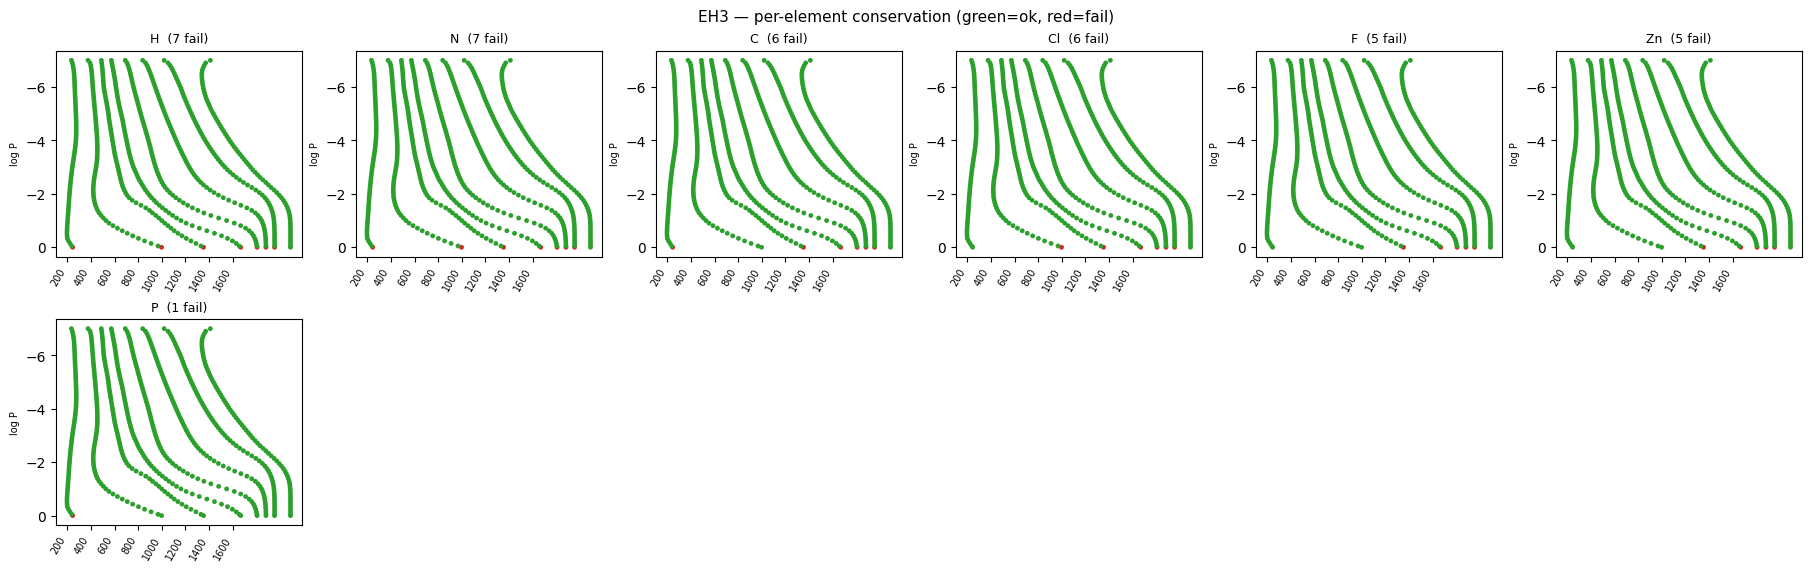


────────────────────────────────────────────────────────────
EL3 — elements with conservation failures:
       H: 61 points
       N: 61 points
      Cl: 59 points
       P: 59 points
       C: 58 points
       F: 58 points
      Zn: 58 points
       O: 54 points
       S: 54 points
  n_tot_cmneg3: 53 points
    eneg: 53 points
      Al: 53 points
      Ca: 53 points
      Co: 53 points
      Cr: 53 points
      Fe: 53 points
       K: 53 points
      Mg: 53 points
      Mn: 53 points
      Na: 53 points
      Ni: 53 points
      Si: 53 points
      Ti: 53 points


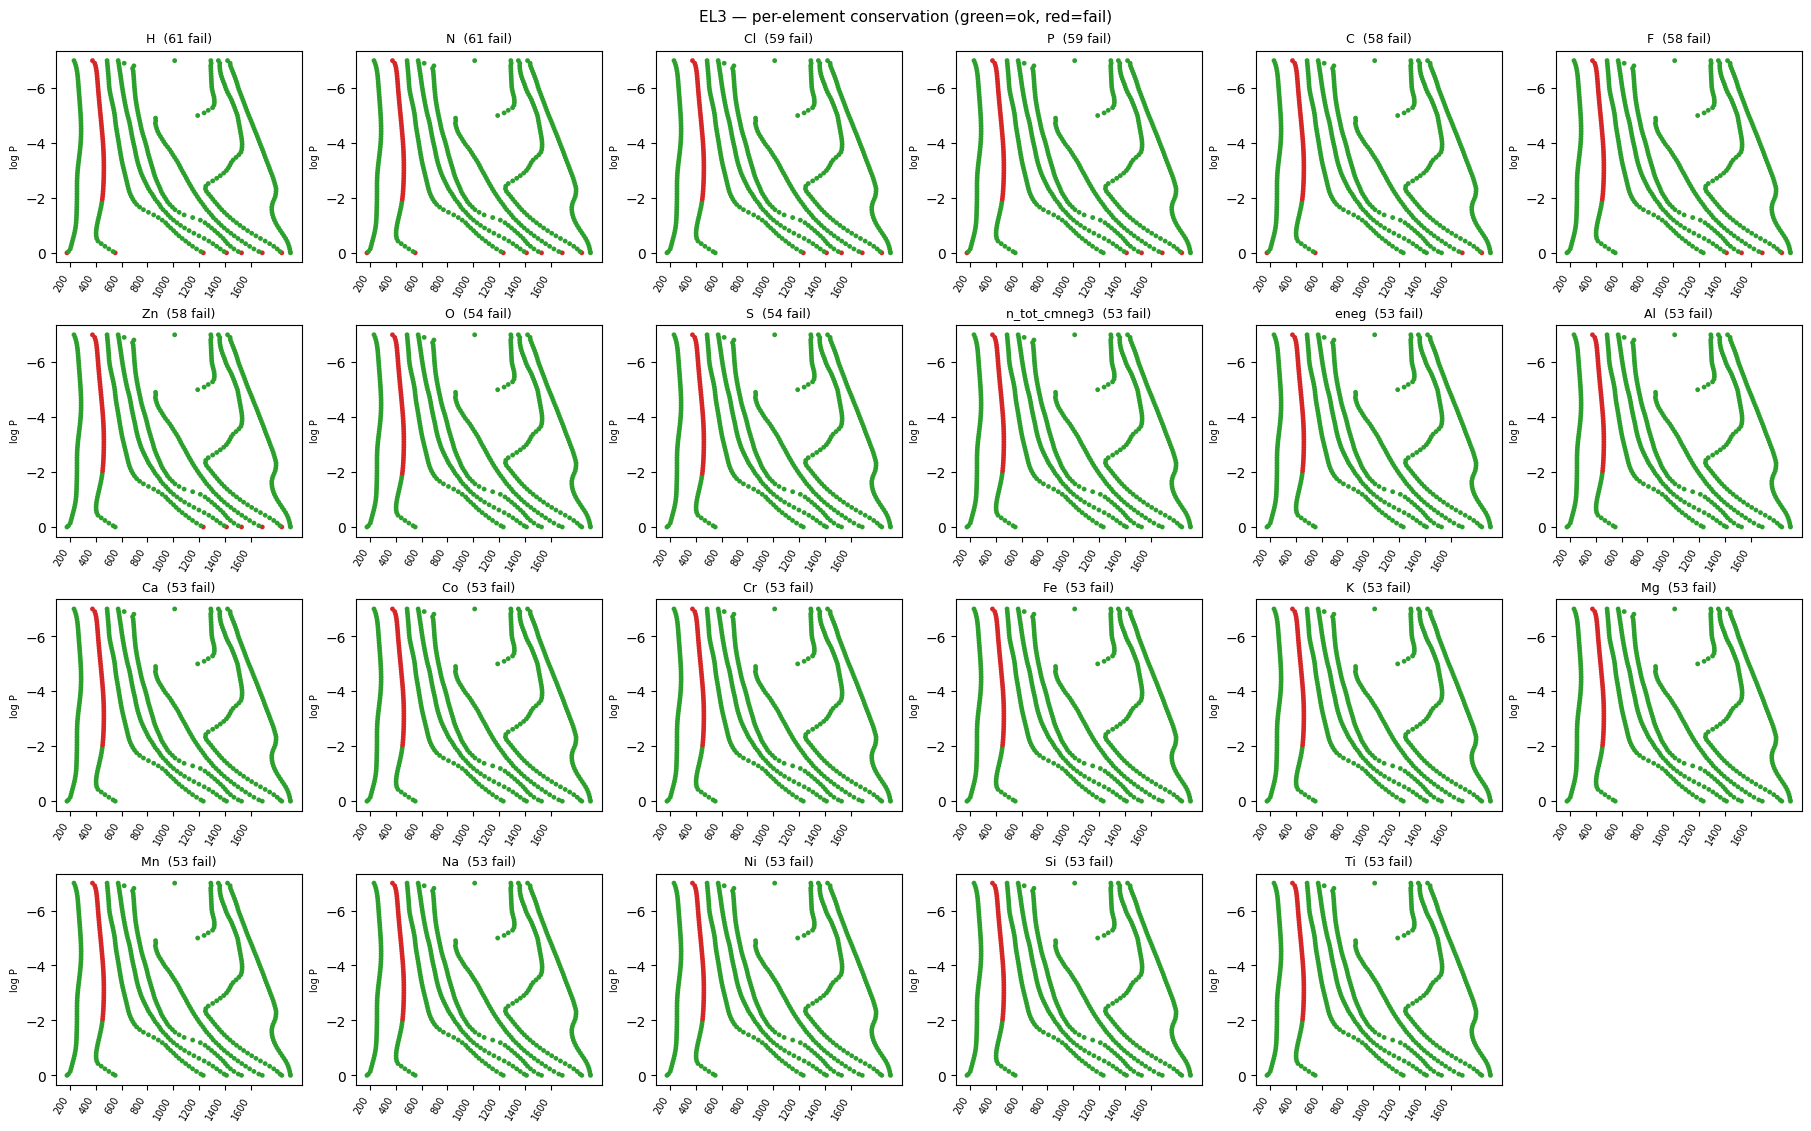


────────────────────────────────────────────────────────────
R3 — elements with conservation failures:
       C: 18 points
       H: 18 points
       N: 18 points
      Cl: 17 points
       F: 17 points
      Al: 16 points
      Co: 16 points
      Fe: 16 points
       K: 16 points
      Mg: 16 points
      Na: 16 points
      Ni: 16 points
       O: 16 points
       P: 16 points
       S: 16 points
      Si: 16 points
      Ti: 16 points
      Zn: 16 points
  n_tot_cmneg3: 15 points
    eneg: 15 points
      Ca: 15 points
      Cr: 15 points
      Mn: 15 points


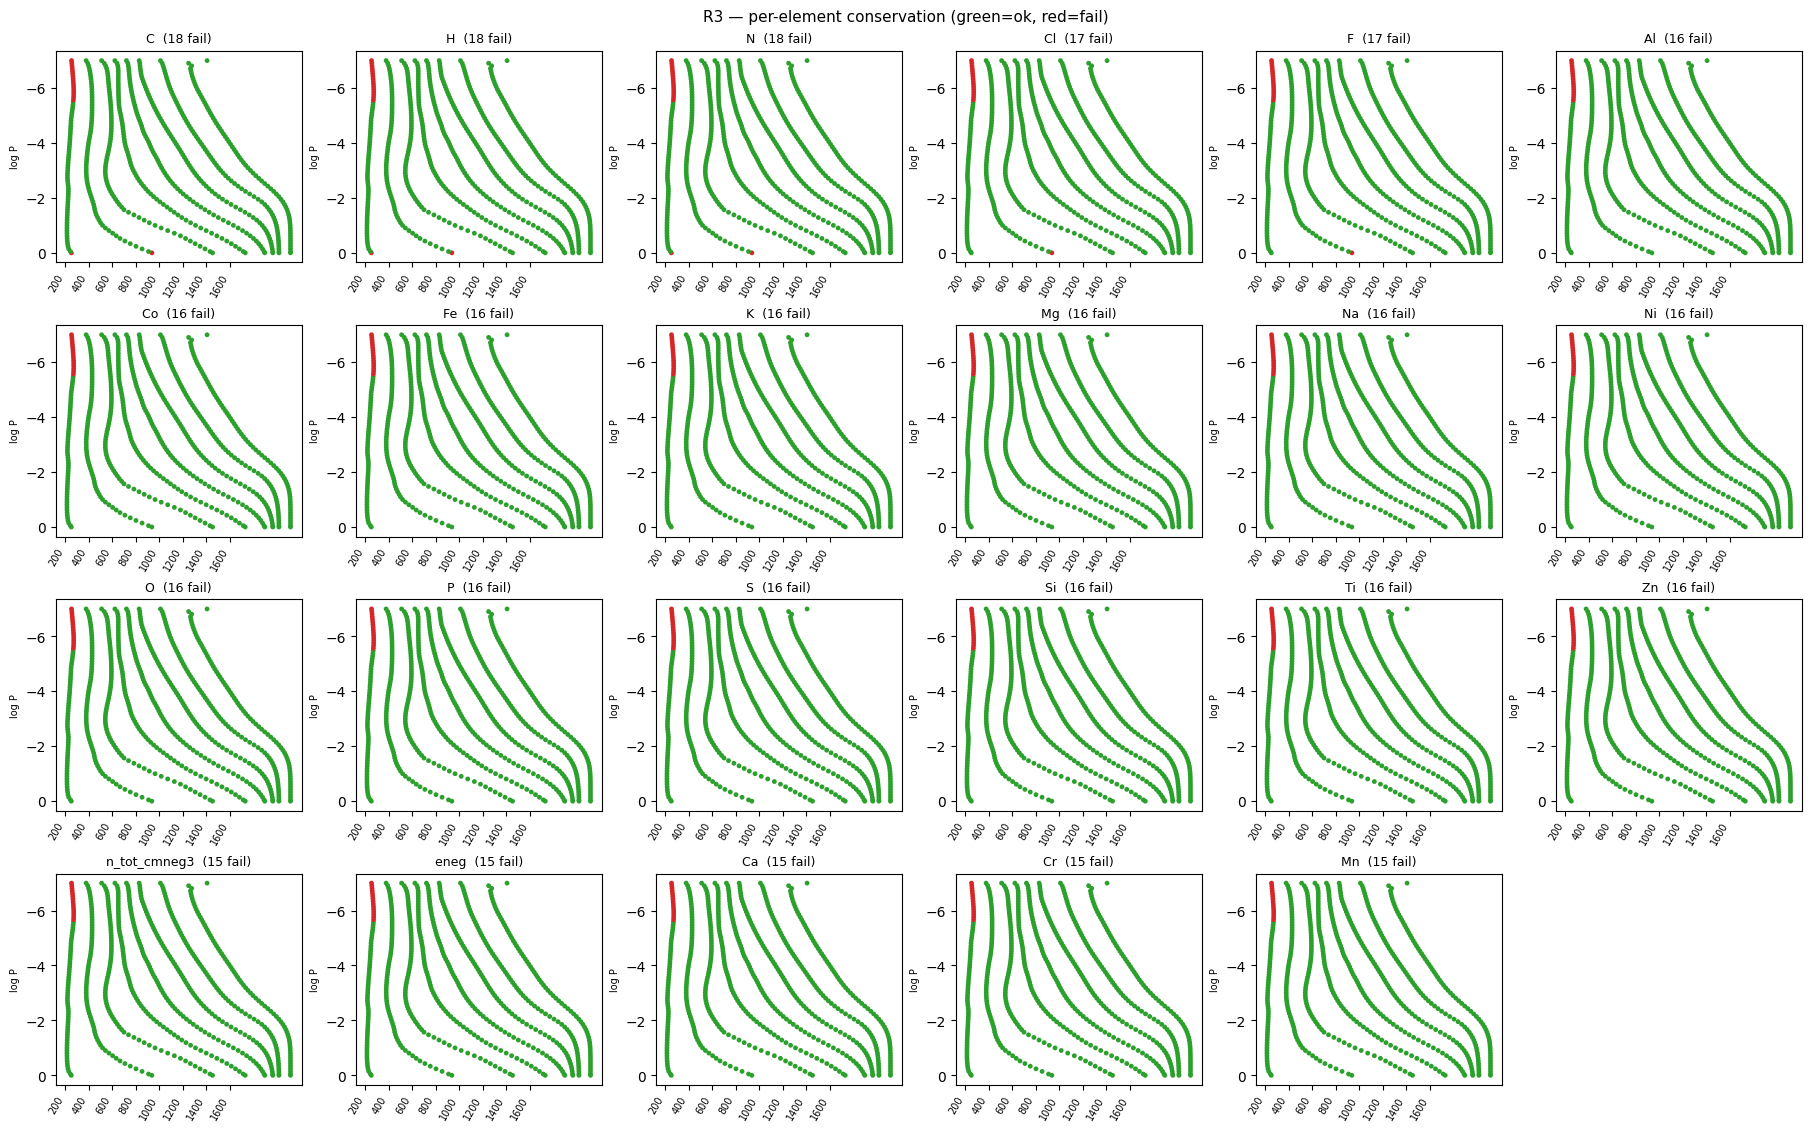


────────────────────────────────────────────────────────────
Krymka(LL3) — elements with conservation failures:
       C: 32 points
       H: 32 points
       N: 32 points
      Al: 30 points
      Ca: 30 points
      Cl: 30 points
      Cr: 30 points
       F: 30 points
      Fe: 30 points
       K: 30 points
      Mg: 30 points
      Na: 30 points
       O: 30 points
       P: 30 points
       S: 30 points
      Si: 30 points
      Zn: 30 points
  n_tot_cmneg3: 29 points
    eneg: 29 points
      Co: 29 points
      Mn: 29 points
      Ni: 29 points
      Ti: 29 points


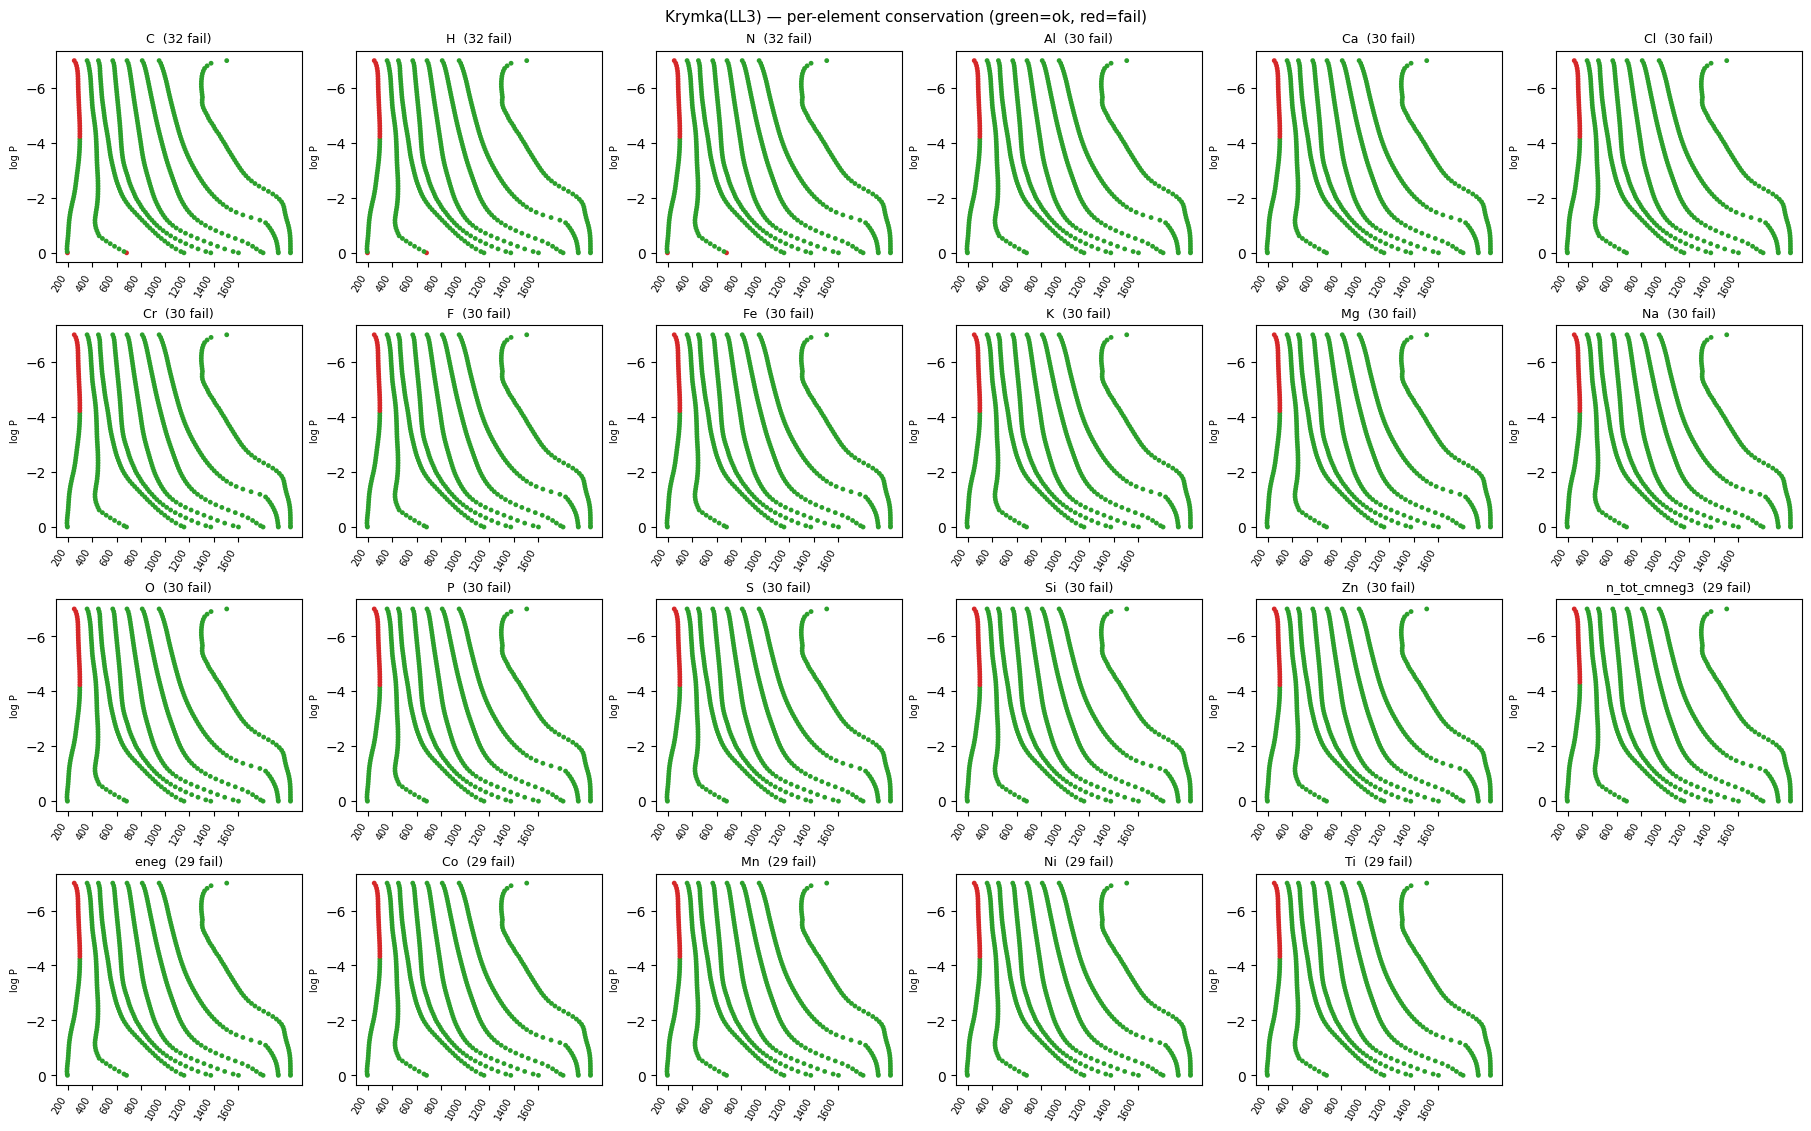


────────────────────────────────────────────────────────────
Bath(H4) — elements with conservation failures:
       C: 8 points
       H: 8 points
       N: 8 points
      Cl: 6 points
       F: 6 points
      Zn: 6 points
       K: 1 points
       P: 1 points


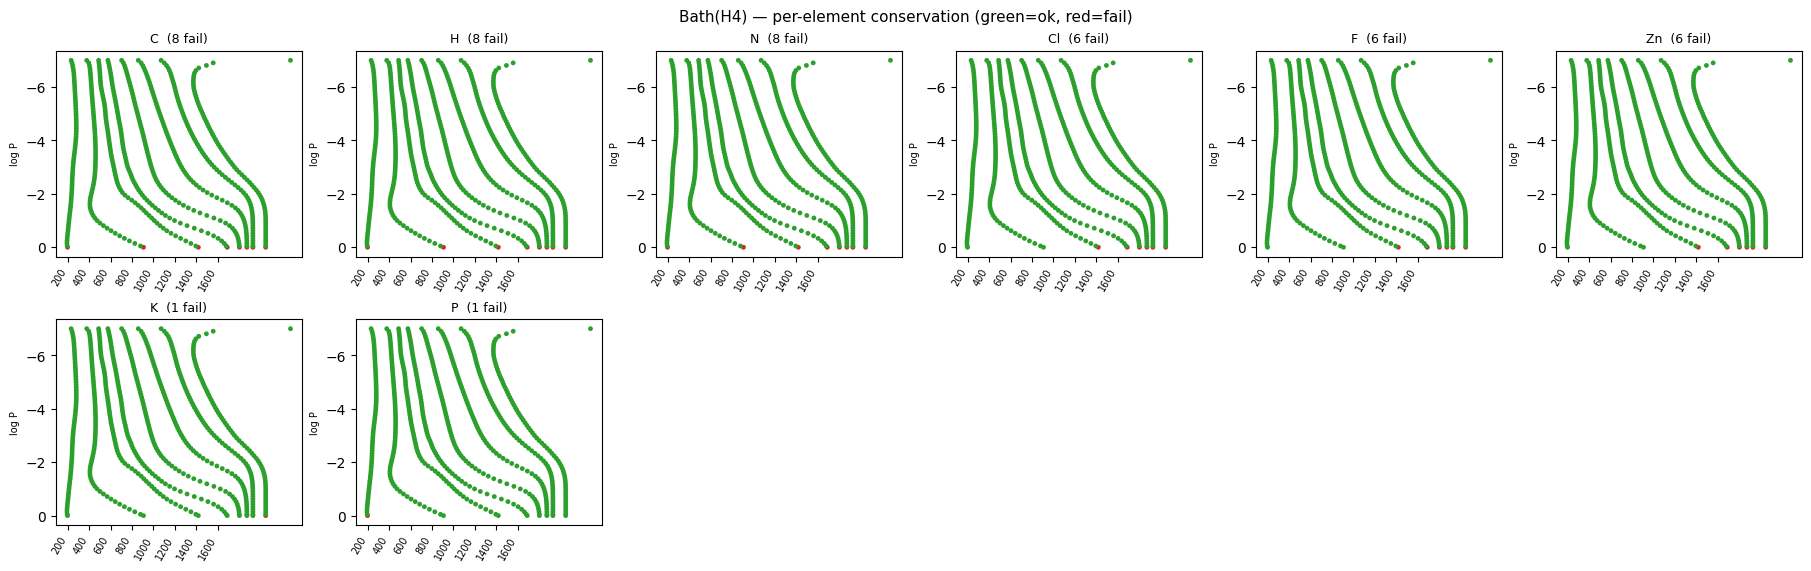

In [6]:
for label, df in all_data.items():
    elem_cols = [c for c in df.columns if c not in FIXED_COLS]
    if not elem_cols:
        print(f"{label}: no element columns found")
        continue

    # bool() cast ensures ~ works regardless of how pandas stored the column
    fail_counts = {
        col: int((~df[col].astype(bool)).sum())
        for col in elem_cols
        if not df[col].astype(bool).all()
    }
    if not fail_counts:
        print(f"{label}: all elements conserved at every point")
        continue

    failing_elems = sorted(fail_counts, key=fail_counts.get, reverse=True)
    print(f"\n{'─'*60}")
    print(f"{label} — elements with conservation failures:")
    for el in failing_elems:
        print(f"  {el:>6s}: {fail_counts[el]} points")

    n_el = len(failing_elems)
    ncols_el = min(6, n_el)
    nrows_el = int(np.ceil(n_el / ncols_el))

    fig, axes = plt.subplots(
        nrows_el, ncols_el,
        figsize=(3.0 * ncols_el, 2.8 * nrows_el),
        constrained_layout=True,
    )
    axes = np.array(axes).flatten()

    for ax, el in zip(axes, failing_elems):
        ok = df[el].astype(bool)
        colors = [STATUS_COLORS[0] if v else STATUS_COLORS[2] for v in ok]

        ax.scatter(df["T_K"], np.log10(df["p_bar"]),
                   c=colors, s=MS, linewidths=0)
        ax.set_xticks(TEMPERATURES)
        ax.set_xticklabels([str(t) for t in TEMPERATURES],
                           rotation=60, ha="right", fontsize=7)
        ax.invert_yaxis()
        ax.set_title(f"{el}  ({fail_counts[el]} fail)", fontsize=9)
        ax.set_ylabel("log P", fontsize=7)

    for ax in axes[n_el:]:
        ax.set_visible(False)

    fig.suptitle(f"{label} — per-element conservation (green=ok, red=fail)",
                 fontsize=11)
    plt.show()

## 4. Failing Points Detail

Tabulates every (T, P) point where `elem_conserved` or `converged` is `fail`,
showing the specific elements that failed.

In [ ]:
for label, df in all_data.items():
    mask = ~df["elem_conserved"].astype(bool) if "elem_conserved" in df.columns \
           else pd.Series(False, index=df.index)
    if "converged" in df.columns:
        mask = mask | ~df["converged"].astype(bool)

    failing = df[mask].copy()
    if failing.empty:
        print(f"{label}: no failing points")
        continue

    elem_cols = [c for c in df.columns if c not in FIXED_COLS]

    def failed_elements(row):
        return ", ".join(el for el in elem_cols
                         if el in row.index and not bool(row[el]))

    failing["failed_elements"] = failing.apply(failed_elements, axis=1)

    display_cols = [c for c in ["T_K", "p_bar", "converged", "elem_conserved",
                                  "iterations", "failed_elements"] if c in failing.columns]
    print(f"\n{label} — {len(failing)} failing point(s):")
    display(failing[display_cols].reset_index(drop=True))